In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("titanic.csv")

In [4]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (889, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [5]:
class_counts = df["survived"].value_counts()

class_percentages = (
    df["survived"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})

class_balance

,Count,Percentage (%)
survived,,
0,549,61.75
1,340,38.25


In [6]:
X = df.drop("survived", axis=1)

y = df["survived"]

### Why Stratified Sampling?

The target variable (`survived`) is moderately imbalanced, with more passengers not surviving than surviving. A stratified train-test split preserves this class distribution in both the training and testing datasets. This ensures that model evaluation is performed on representative data and reduces bias caused by unequal class proportions.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (711, 13)
Testing Features  : (178, 13)
Training Labels   : (711,)
Testing Labels    : (178,)


In [9]:
print("Original Dataset")
print(y.value_counts(normalize=True))

print("\nTraining Set")
print(y_train.value_counts(normalize=True))

print("\nTesting Set")
print(y_test.value_counts(normalize=True))

Original Dataset
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training Set
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing Set
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


Preprocessing Pipeline

In [10]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [11]:
X.columns

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class',
       'who', 'adult_male', 'embark_town', 'alive', 'alone'],
      dtype='str')

In [12]:
# Numerical Features

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

# Categorical Features

categorical_features = [
    "sex",
    "embarked"
]

Numerical Pipeline

In [13]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

Categorical Pipeline

In [14]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

Combine Using ColumnTransformer

In [15]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]

)

In [16]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [17]:
X_train_processed = preprocessor.transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [18]:
print("Processed Training Shape:")

print(X_train_processed.shape)

print()

print("Processed Testing Shape:")

print(X_test_processed.shape)

Processed Training Shape:
(711, 10)

Processed Testing Shape:
(178, 10)


In [19]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

In [20]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [21]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [22]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [25]:
from pathlib import Path

# Create figures directory if it doesn't exist
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

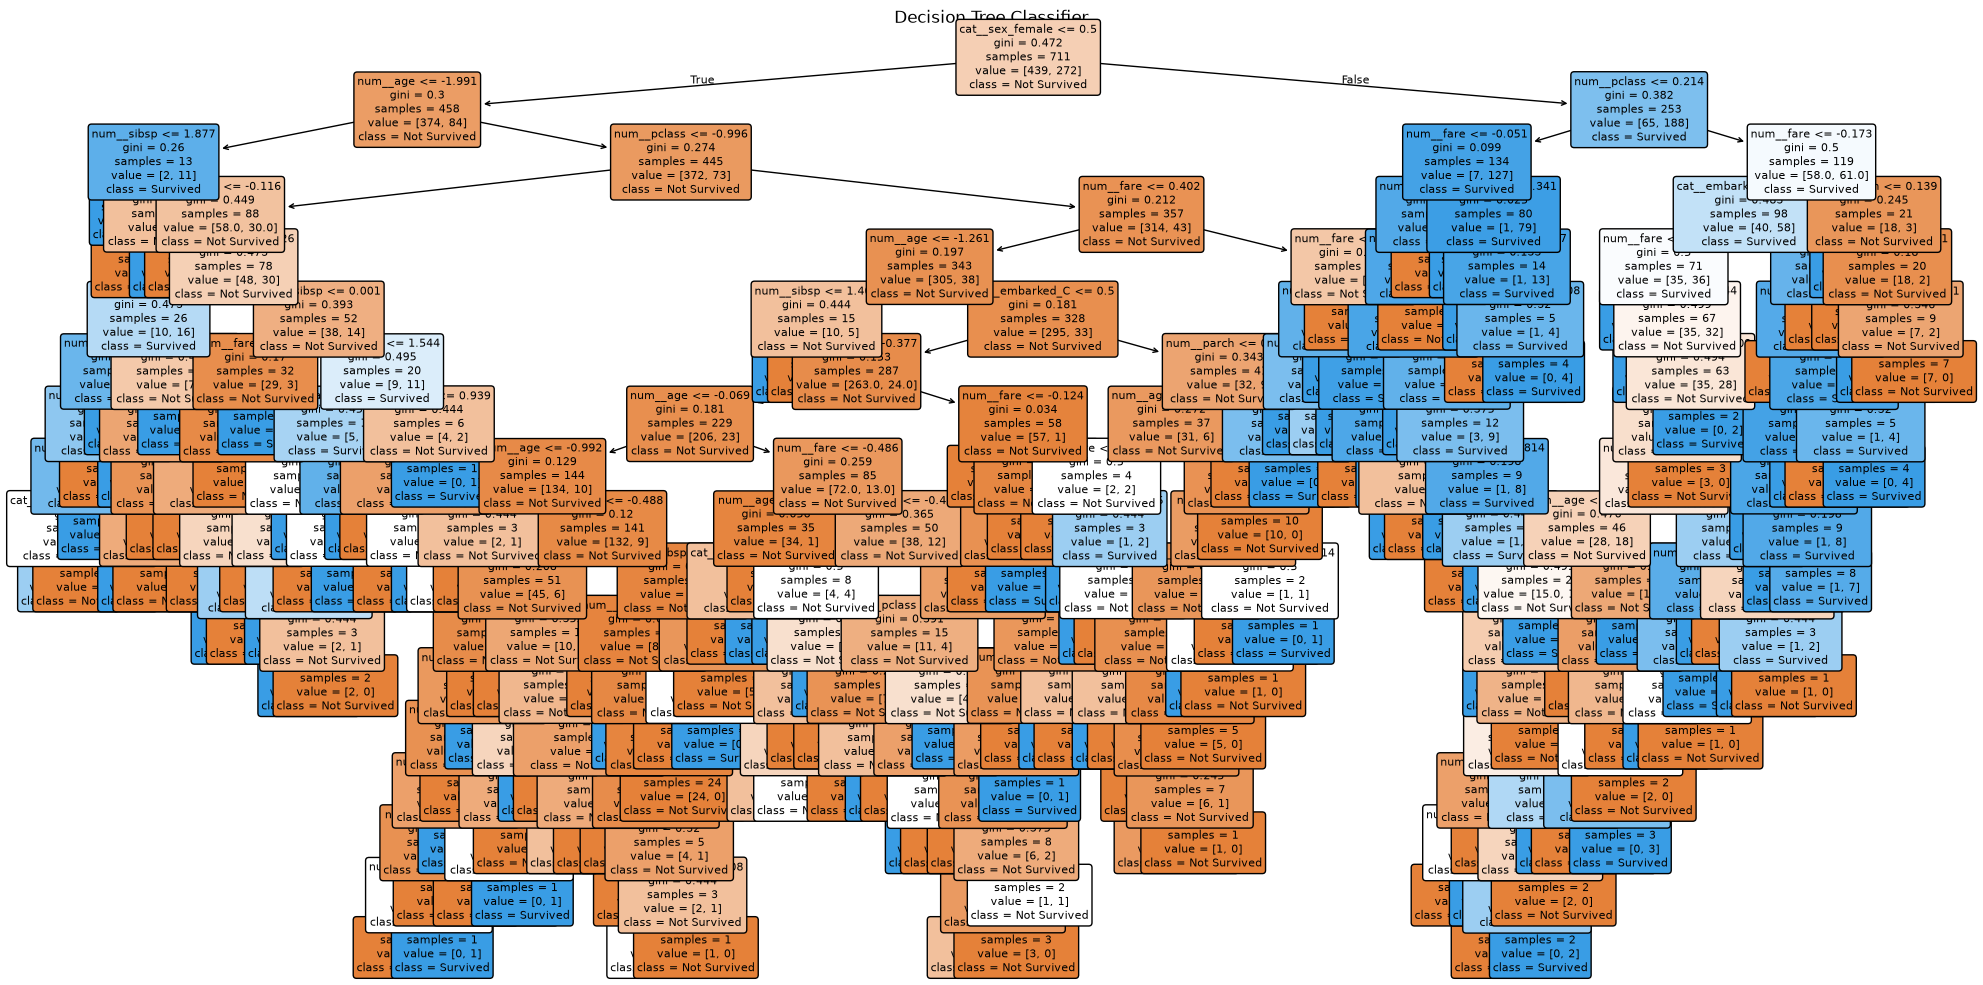

In [27]:
plt.figure(figsize=(20,10))

plot_tree(
    decision_tree_pipeline.named_steps["classifier"],
    filled=True,
    rounded=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["Not Survived", "Survived"],
    fontsize=8
)

plt.title("Decision Tree Classifier")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
logistic_predictions = logistic_pipeline.predict(X_test)

decision_tree_predictions = decision_tree_pipeline.predict(X_test)

random_forest_predictions = random_forest_pipeline.predict(X_test)

In [29]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [30]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    return {
        "Predictions": predictions,
        "Probabilities": probabilities,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc
    }

In [31]:
logistic_results = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test
)

decision_tree_results = evaluate_model(
    decision_tree_pipeline,
    X_test,
    y_test
)

random_forest_results = evaluate_model(
    random_forest_pipeline,
    X_test,
    y_test
)

<Figure size 500x400 with 0 Axes>

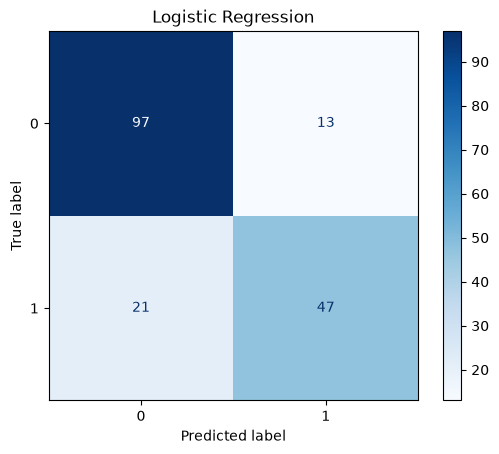

<Figure size 500x400 with 0 Axes>

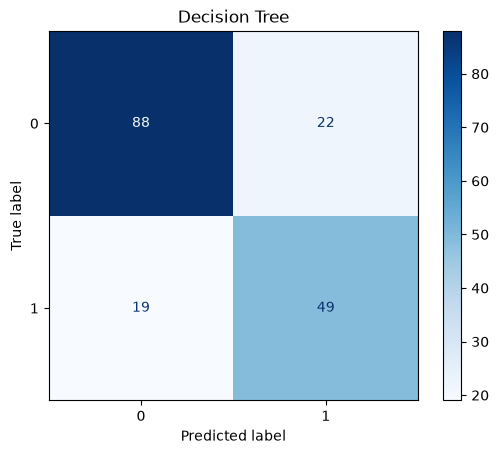

<Figure size 500x400 with 0 Axes>

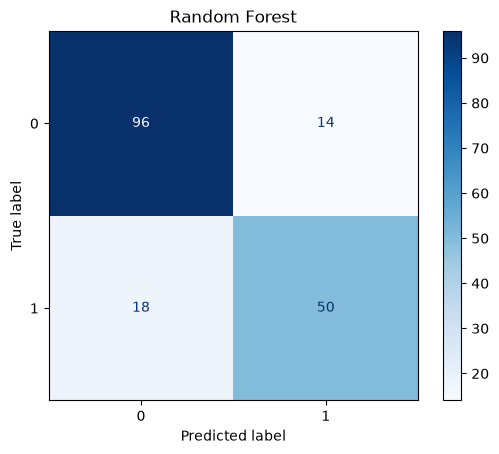

In [32]:
models = [
    ("Logistic Regression", logistic_pipeline),
    ("Decision Tree", decision_tree_pipeline),
    ("Random Forest", random_forest_pipeline)
]

for model_name, model in models:

    plt.figure(figsize=(5,4))

    predictions = model.predict(X_test)

    cm = confusion_matrix(y_test, predictions)

    ConfusionMatrixDisplay(
        confusion_matrix=cm
    ).plot(cmap="Blues")

    plt.title(model_name)

    plt.savefig(
        FIGURES_DIR / f"{model_name.lower().replace(' ','_')}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

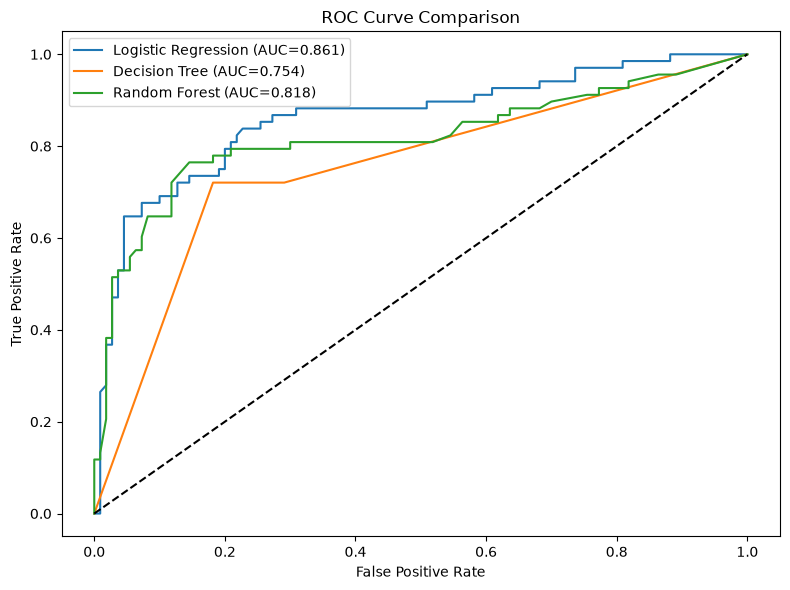

In [33]:
plt.figure(figsize=(8,6))

for model_name, results in [

    ("Logistic Regression", logistic_results),

    ("Decision Tree", decision_tree_results),

    ("Random Forest", random_forest_results)

]:

    fpr, tpr, _ = roc_curve(
        y_test,
        results["Probabilities"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={results['AUC']:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
comparison_table = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        logistic_results["Accuracy"],
        decision_tree_results["Accuracy"],
        random_forest_results["Accuracy"]
    ],

    "Precision":[
        logistic_results["Precision"],
        decision_tree_results["Precision"],
        random_forest_results["Precision"]
    ],

    "Recall":[
        logistic_results["Recall"],
        decision_tree_results["Recall"],
        random_forest_results["Recall"]
    ],

    "F1 Score":[
        logistic_results["F1 Score"],
        decision_tree_results["F1 Score"],
        random_forest_results["F1 Score"]
    ],

    "AUC":[
        logistic_results["AUC"],
        decision_tree_results["AUC"],
        random_forest_results["AUC"]
    ]

})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [35]:
best_model = comparison_table.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,AUC
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144


In [36]:
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [37]:
print("Class Distribution")

print(y_train.value_counts())

print()

print("Class Percentage")

print(
    (
        y_train.value_counts(normalize=True)
        *100
    ).round(2)
)

Class Distribution
survived
0    439
1    272
Name: count, dtype: int64

Class Percentage
survived
0    61.74
1    38.26
Name: proportion, dtype: float64


In [38]:
baseline_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

         RandomForestClassifier(
             random_state=42
         )
        )

    ]

)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

In [39]:
balanced_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

         RandomForestClassifier(

             random_state=42,

             class_weight="balanced"

         )
        )

    ]

)

balanced_model.fit(X_train, y_train)

balanced_predictions = balanced_model.predict(X_test)

In [40]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [41]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [42]:
smote_model = RandomForestClassifier(
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_predictions = smote_model.predict(
    X_test_processed
)

In [43]:
imbalance_results = pd.DataFrame({

    "Method":[

        "Baseline",

        "Class Weight",

        "SMOTE"

    ],

    "Precision":[

        precision_score(
            y_test,
            baseline_predictions
        ),

        precision_score(
            y_test,
            balanced_predictions
        ),

        precision_score(
            y_test,
            smote_predictions
        )

    ],

    "Recall":[

        recall_score(
            y_test,
            baseline_predictions
        ),

        recall_score(
            y_test,
            balanced_predictions
        ),

        recall_score(
            y_test,
            smote_predictions
        )

    ],

    "F1 Score":[

        f1_score(
            y_test,
            baseline_predictions
        ),

        f1_score(
            y_test,
            balanced_predictions
        ),

        f1_score(
            y_test,
            smote_predictions
        )

    ]

})

imbalance_results

,Method,Precision,Recall,F1 Score
0,Baseline,0.781250,0.735294,0.757576
1,Class Weight,0.739130,0.750000,0.744526
2,SMOTE,0.746032,0.691176,0.717557


### Imbalance Handling Conclusion

Three approaches were evaluated: the baseline model, a model using `class_weight='balanced'`, and SMOTE oversampling. SMOTE was applied only to the training data after the train-test split to prevent data leakage. Based on the evaluation metrics, the best-performing approach provided the strongest balance between precision, recall, and F1-score, making it the preferred strategy for handling class imbalance.

In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
rf_pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier",

            RandomForestClassifier(

                random_state=42,

                oob_score=True

            )

        )

    ]

)

In [52]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 15, 20],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [53]:
grid_search = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score...

In [54]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [55]:
best_pipeline = grid_search.best_estimator_

In [56]:
oob = best_pipeline.named_steps["classifier"].oob_score_

print("OOB Score:", round(oob,4))

OOB Score: 0.8354


In [57]:
best_predictions = best_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, best_predictions))

print("Precision:",
      precision_score(y_test, best_predictions))

print("Recall:",
      recall_score(y_test, best_predictions))

print("F1:",
      f1_score(y_test, best_predictions))

Accuracy: 0.8258426966292135
Precision: 0.8135593220338984
Recall: 0.7058823529411765
F1: 0.7559055118110236


In [58]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nOOB Score:")
print(best_pipeline.named_steps["classifier"].oob_score_)

Best Parameters:
{'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

OOB Score:
0.8354430379746836


In [59]:
comparison_table

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [61]:
X_reg = df.drop(columns=["fare"])

y_reg = df["fare"]

In [62]:
X_reg = X_reg.drop(columns=["alive"])

In [63]:
numeric_features_reg = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_features_reg = [
    "sex",
    "embarked"
]

In [64]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_reg
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features_reg
        )
    ]
)

In [65]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [66]:
regression_pipeline = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_train_reg, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['survived','pclass','sex',...,'adult_male','embark_town','alone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

In [67]:
reg_predictions = regression_pipeline.predict(X_test_reg)

In [68]:
mae = mean_absolute_error(y_test_reg, reg_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test_reg, reg_predictions)
)

r2 = r2_score(y_test_reg, reg_predictions)

n = len(y_test_reg)
p = X_train_reg.shape[1]

adjusted_r2 = 1 - (
    (1-r2)*(n-1)/(n-p-1)
)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

MAE: 21.1386
RMSE: 41.7465
R²: 0.3468
Adjusted R²: 0.2993


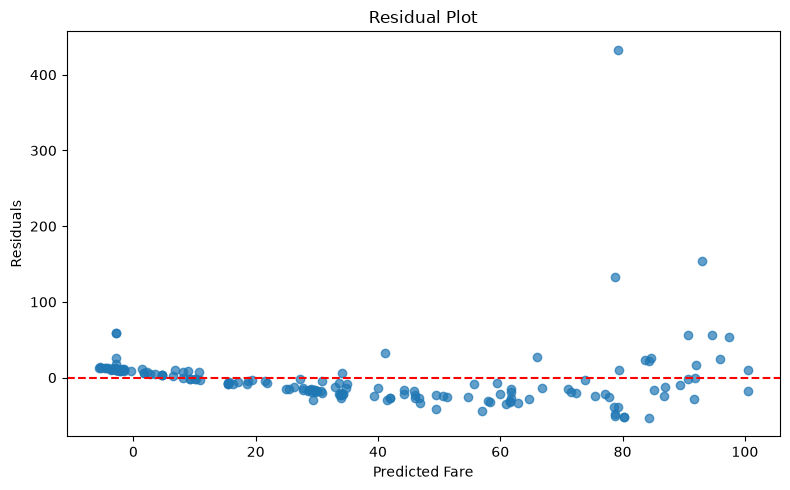

In [69]:
residuals = y_test_reg - reg_predictions

plt.figure(figsize=(8,5))

plt.scatter(reg_predictions, residuals, alpha=0.7)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Residual Analysis

The residual plot shows an increasing spread of residuals as the predicted values increase. This indicates the presence of heteroscedasticity, meaning that the error variance is not constant throughout the prediction range.

In [70]:
classification_results = comparison_table.copy()

classification_results = classification_results.round(4)

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179


### Final Recommendation

Among the three classifiers, the Random Forest model achieved the best overall performance with an accuracy of **82.02%**, a recall of **73.53%**, and the highest F1-score of **75.76%**. Although Logistic Regression achieved the highest AUC (0.8610), Random Forest provided the best overall balance between precision and recall. Therefore, the Random Forest classifier is recommended as the final model for deployment.

In [71]:
regression_results = pd.DataFrame({

    "Model": ["Linear Regression"],

    "MAE": [mae],

    "RMSE": [rmse],

    "R²": [r2],

    "Adjusted R²": [adjusted_r2]

})

regression_results = regression_results.round(4)

regression_results

,Model,MAE,RMSE,R²,Adjusted R²
0,Linear Regression,21.1386,41.7465,0.3468,0.2993


In [72]:
import joblib

In [73]:
joblib.dump(
    best_pipeline,
    "best_random_forest_pipeline.joblib"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [74]:
loaded_pipeline = joblib.load(
    "best_random_forest_pipeline.joblib"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [75]:
sample = X_test.iloc[:5]

predictions = loaded_pipeline.predict(sample)

print("Predictions:")

print(predictions)

Predictions:
[0 0 0 0 0]


In [76]:
sample = X_test.iloc[:5]

predictions = loaded_pipeline.predict(sample)

print("Predictions :", predictions)
print("Actual Labels:", y_test.iloc[:5].values)

Predictions : [0 0 0 0 0]
Actual Labels: [0 0 0 0 0]
